# clean_swaps

In [ ]:
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from util import clean_swaps2, pose_df_to_movement_ds, plot_speed, shade_mask_regions
from aeon.dj_pipeline import fetch_stream, tracking, acquisition
from aeon.dj_pipeline.utils import tracking_utils
from matplotlib import pyplot as plt
from movement.kinematics import compute_speed, compute_pairwise_distances
from movement.transforms import scale

In [86]:
from tqdm.notebook import tqdm
def clean_swaps3(df: pd.DataFrame, region_df: pd.DataFrame) -> pd.DataFrame:
    """Swap correction for dual mouse tracking.

    Filters out-of-bounds points first,
    then does identity assignment with majority voting to fix track swaps.

    - Pre-cleaning: removes points outside arena/nest bounds
    - Early frames: filled with raw data before first complete observation
    - Swap detection: uses frame-to-frame distance minimization
    - Identity correction: SLEAP-style majority vote at the end
    - Swap marking: sets identity_likelihood=NaN on locally swapped frames

    Parameters:
    - df: DataFrame with tracking data (x, y, identity_name columns)
    - region_df: DataFrame containing arena region data with columns:
        - region_name: name of the region (e.g., 'ArenaCenter', 'ArenaOuterRadius', 'NestRegion')
        - region_data: dictionary containing region-specific data

    Returns:
    - DataFrame with cleaned tracking data, same structure as input but corrected x,y coords
      and identity_likelihood=NaN on locally swapped frames

    Example:
        To retrieve region_df from the database:
        ```python
        active_region_query = acquisition.EpochConfig.ActiveRegion & (acquisition.Chunk & chunk_key)
        region_df = active_region_query.fetch(format="frame")
        ```
    """

    # Helper to extract region values
    def get_region_value(region_name):
        mask = region_df.index.get_level_values("region_name") == region_name
        if mask.any():
            return region_df.loc[mask, "region_data"].iloc[0]
        return None

    # Parse arena geometry
    arena_center = get_region_value("ArenaCenter")
    arena_outer_radius = get_region_value("ArenaOuterRadius")
    nest_region = get_region_value("NestRegion")

    if arena_center is None or arena_outer_radius is None:
        raise ValueError(
            "Could not find ArenaCenter or ArenaOuterRadius in region data"
        )

    # Coords + radius
    center_x = float(arena_center["X"])
    center_y = float(arena_center["Y"])
    outer_radius = float(arena_outer_radius) + 10

    # Nest boundary points
    nest_x_coords = []
    nest_y_coords = []
    if nest_region and "ArrayOfPoint" in nest_region:
        for point in nest_region["ArrayOfPoint"]:
            nest_x_coords.append(float(point["X"]))
            nest_y_coords.append(float(point["Y"]))

    # Filter out-of-bounds points before cleaning
    if len(nest_x_coords) > 0:
        # Arena circle check
        dist2 = (df["x"] - center_x) ** 2 + (df["y"] - center_y) ** 2
        inside_arena = dist2 <= outer_radius**2

        # Nest bounding box with padding
        nx_min, nx_max = min(nest_x_coords) - 10, max(nest_x_coords) + 10
        ny_min, ny_max = min(nest_y_coords) - 10, max(nest_y_coords) + 10
        inside_nest = df["x"].between(nx_min, nx_max) & df["y"].between(ny_min, ny_max)

        # Keep arena OR nest points
        df = df[inside_arena | inside_nest]
    else:
        # Arena only if no nest
        dist2 = (df["x"] - center_x) ** 2 + (df["y"] - center_y) ** 2
        inside_arena = dist2 <= outer_radius**2
        df = df[inside_arena]

    # Swap correction starts here
    # 1) setup data for processing
    df = df.sort_index()
    ids = df["identity_name"].unique()
    if len(ids) != 2:
        raise ValueError("Expected exactly two identities, found: {}".format(ids))

    # 2) Prep for merge later
    df2 = df.reset_index()
    time_col = df2.columns[0]  # timestamp column name

    # 3) Reshape to 2×T arrays
    times = df.index.unique().values
    T = len(times)
    x_raw = (
        df.set_index("identity_name", append=True)["x"]
        .unstack("identity_name")
        .to_numpy()
        .T
    )
    y_raw = (
        df.set_index("identity_name", append=True)["y"]
        .unstack("identity_name")
        .to_numpy()
        .T
    )

    # 4) Init cleaned arrays + swap tracking
    x_clean = np.full_like(x_raw, np.nan)
    y_clean = np.full_like(y_raw, np.nan)
    swapped_flags = np.zeros(T, dtype=bool)  # Track local swaps

    # 5) Find first complete frame
    valid = np.isfinite(x_raw).all(axis=0)
    first_i = np.argmax(valid)

    # Fill early frames with raw data
    if first_i > 0:
        x_clean[:, :first_i] = x_raw[:, :first_i]
        y_clean[:, :first_i] = y_raw[:, :first_i]

    # Start tracking from first complete frame
    last_x = x_raw[:, first_i].copy()
    last_y = y_raw[:, first_i].copy()
    x_clean[:, first_i] = last_x
    y_clean[:, first_i] = last_y

    # Vote counter for final identity assignment
    track_votes = np.zeros((2, 2), dtype=np.int64)

    # Count first frame if valid
    if valid[first_i]:
        track_votes[0, 0] += 1
        track_votes[1, 1] += 1

    # 6) Main loop: swap correction + voting
    for t in tqdm(range(first_i + 1, T), desc="Cleaning frames"):
        # Missing data: carry forward last known positions
        # if any of the x_raw or y_raw values are NaN
        # fill the corresponding x_clean and y_clean
        # with last known positions, otherwise keep original values
        if np.isnan(x_raw[:, t]).any():
            for k in (0, 1):
                if np.isnan(x_raw[k, t]):
                    x_clean[k, t] = last_x[k]
                    y_clean[k, t] = last_y[k]
                else:
                    x_clean[k, t] = x_raw[k, t]
                    y_clean[k, t] = y_raw[k, t]
            continue

        # Mice too close: keep original assignment
        inter_mouse_dist = np.hypot(
            x_raw[0, t] - x_raw[1, t], y_raw[0, t] - y_raw[1, t]
        )
        if inter_mouse_dist < 115:
            x_clean[:, t] = x_raw[:, t]
            y_clean[:, t] = y_raw[:, t]
            track_votes[0, 0] += 1
            track_votes[1, 1] += 1
            last_x = x_raw[:, t].copy()
            last_y = y_raw[:, t].copy()
            continue

        # Distance-based swap decision
        d_same = np.sum(np.hypot(x_raw[:, t] - last_x, y_raw[:, t] - last_y))
        d_swap = np.sum(np.hypot(x_raw[::-1, t] - last_x, y_raw[::-1, t] - last_y))

        # Too far even with best assignment: carry forward
        if min(d_same, d_swap) > 90:
            x_clean[:, t] = last_x
            y_clean[:, t] = last_y
            continue

        # Assign based on shortest total distance
        if d_same <= d_swap:
            x_clean[:, t] = x_raw[:, t]
            y_clean[:, t] = y_raw[:, t]
            track_votes[0, 0] += 1
            track_votes[1, 1] += 1
        else:
            x_clean[:, t] = x_raw[::-1, t]
            y_clean[:, t] = y_raw[::-1, t]
            track_votes[0, 1] += 1
            track_votes[1, 0] += 1
            swapped_flags[t] = True  # Mark local swap

        # Update reference for next frame
        last_x = x_clean[:, t].copy()
        last_y = y_clean[:, t].copy()

    # 7) Global identity correction via majority vote
    need_swap = track_votes[0, 1] > track_votes[0, 0]
    if need_swap:
        x_clean = x_clean[::-1, :]
        y_clean = y_clean[::-1, :]
        # Flip swap flags too
        swapped_flags = swapped_flags[::-1]

    # 8) Build output dataframe
    cleaned = pd.DataFrame(
        {
            time_col: np.repeat(times, 2),
            "identity_name": np.tile(ids, T),
            "x": x_clean.ravel(order="F"),
            "y": y_clean.ravel(order="F"),
        }
    )

    # 9) Merge back with original data (drop old x,y)
    df2_noxy = df2.drop(columns=["x", "y"])
    result = (
        df2_noxy.merge(cleaned, on=[time_col, "identity_name"], how="right")
        .set_index(time_col)
        .sort_index()
    )

    # 10) Mark swapped frames in likelihood
    if "identity_likelihood" in result.columns:
        mask = result.index.isin(times[swapped_flags])
        result.loc[mask, "identity_likelihood"] = np.nan

    return result

## Query centroid data from the database

### social0.2-aeon3

In [4]:
start_time = pd.Timestamp("2024-02-09 17:00:00")
end_time = start_time + pd.Timedelta(minutes=10)
key = {
    "experiment_name": "social0.2-aeon3",
    "chunk_start": start_time,
}

### social0.4-aeon4

In [97]:
start_time = pd.Timestamp("2024-08-28 21:10:00")
end_time = start_time + pd.Timedelta(minutes=10)
key = {
    "experiment_name": "social0.4-aeon4",
    "chunk_start": start_time.floor("h"),
}

In [98]:
centroid_query = (
    tracking.SLEAPTracking.PoseIdentity.proj("identity_name", "identity_likelihood")
    * tracking.SLEAPTracking.AnchorPart
    & key
)
df = fetch_stream(centroid_query)[start_time:end_time]
df = df.sort_index()
ids = df["identity_name"].unique()
active_region_query = acquisition.EpochConfig.ActiveRegion & (acquisition.Chunk & key)
region_df = active_region_query.fetch(format="frame")

In [100]:
df_raw = df.copy(deep=True)
df_clean = tracking_utils.clean_swaps(df_raw, region_df)
df_adjusted = clean_swaps3(df_raw, region_df)
df_raw.rename(
    columns={
        "identity_name": "identity",
        "likelihood": "part_likelihood",
    },
    inplace=True,
)
df_raw["part"] = "centroid"
df_adjusted.rename(
    columns={
        "identity_name": "identity",
        "likelihood": "part_likelihood",
    },
    inplace=True,
)
df_adjusted["part"] = "centroid"
df_clean.rename(
    columns={
        "identity_name": "identity",
        "likelihood": "part_likelihood",
    },
    inplace=True,
)
df_clean["part"] = "centroid"

Cleaning frames: 100%|██████████| 30000/30000 [00:00<00:00, 126582.41it/s]


Cleaning frames:   0%|          | 0/30000 [00:00<?, ?it/s]

## Convert to movement dataset

In [101]:
ds_centroid = pose_df_to_movement_ds(df_raw)
ds_centroid_clean = pose_df_to_movement_ds(df_clean)
ds_centroid_adjusted = pose_df_to_movement_ds(df_adjusted)

## Plot position and inter-mouse distances

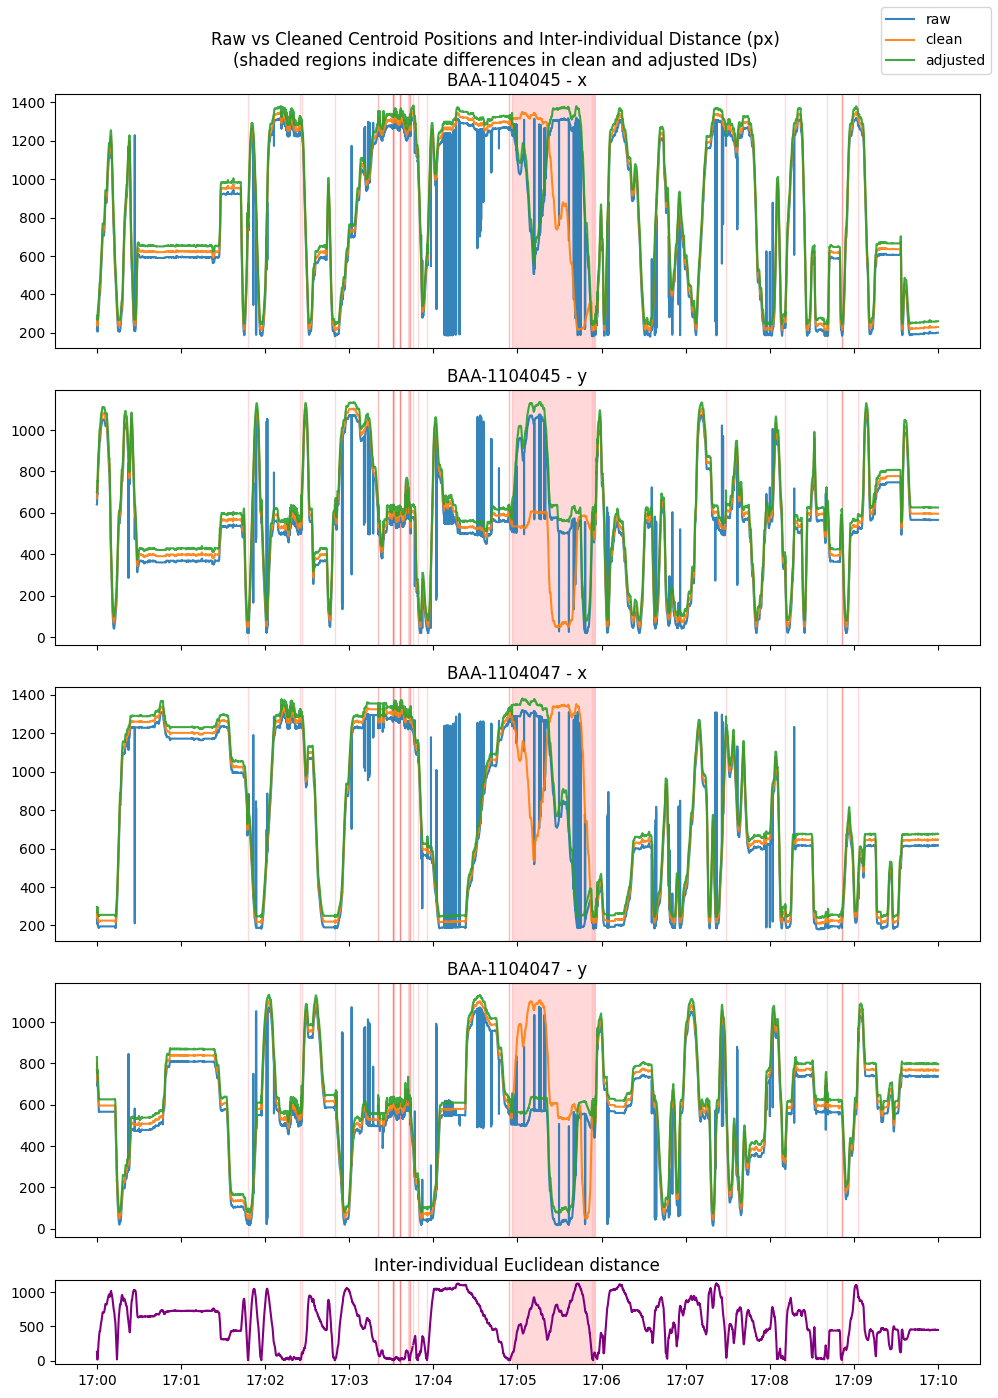

In [26]:
# Compute the difference mask between cleaned and adjusted IDs
diff_mask = (
    ds_centroid_clean.position.squeeze() != ds_centroid_adjusted.position.squeeze()
).isel(space=0, individuals=0)
# Compute inter-individual distances for the cleaned dataset
inter_ind_dist = compute_pairwise_distances(
    ds_centroid_clean.position, dim="individuals", pairs="all", metric="euclidean"
)
# Plot
spaces = ds_centroid.space.values
individuals = ds_centroid.individuals.values
nrows = len(individuals) * len(spaces)
ncols = 1
# Add 1 extra row for the inter-individual distance plot, make it shorter
height_ratios = [3] * nrows + [1]
fig, axes = plt.subplots(
    nrows=nrows + 1,
    ncols=ncols,
    figsize=(10, 3 * nrows + 2),
    sharex=True,
    gridspec_kw={"height_ratios": height_ratios},
)
axes = np.array(axes).reshape(-1)
offsets = [0, 30, 60]
datasets = [
    (ds_centroid, "raw", offsets[0]),
    (ds_centroid_clean, "clean", offsets[1]),
    (ds_centroid_adjusted, "adjusted", offsets[2]),
]
# Main plots
for i, ind in enumerate(individuals):
    for j, space in enumerate(spaces):
        ax_idx = i * len(spaces) + j
        ax = axes[ax_idx]
        for ds, label, offset in datasets:
            y = ds.position.squeeze().sel(space=space, individuals=ind)
            ax.plot(
                y.time,
                y + offset,
                linestyle="-",
                alpha=0.9,
                label=label if (ind == individuals[0] and space == spaces[0]) else None,
            )
        ax.set_title(f"{ind} - {space}")
        # Shade regions where IDs differ
        shade_mask_regions(ax, diff_mask)

# Inter-individual distance plot (bottom row)
ax_dist = axes[-1]
ax_dist.plot(
    inter_ind_dist.time,
    inter_ind_dist.values,
    color="purple",
)
# Shade regions where IDs differ
shade_mask_regions(ax_dist, diff_mask)
ax_dist.set_title("Inter-individual Euclidean distance")
# Shared legend for the main plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    ["raw", "clean", "adjusted"],
)
fig.suptitle(
    "Raw vs Cleaned Centroid Positions and Inter-individual Distance (px)\n"
    "(shaded regions indicate differences in clean and adjusted IDs)",
)
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout()
plt.show()

In [49]:
diff_mask = ~np.isclose(ds_centroid_clean.position.squeeze().values, ds_centroid_adjusted.position.squeeze().values, equal_nan=True)


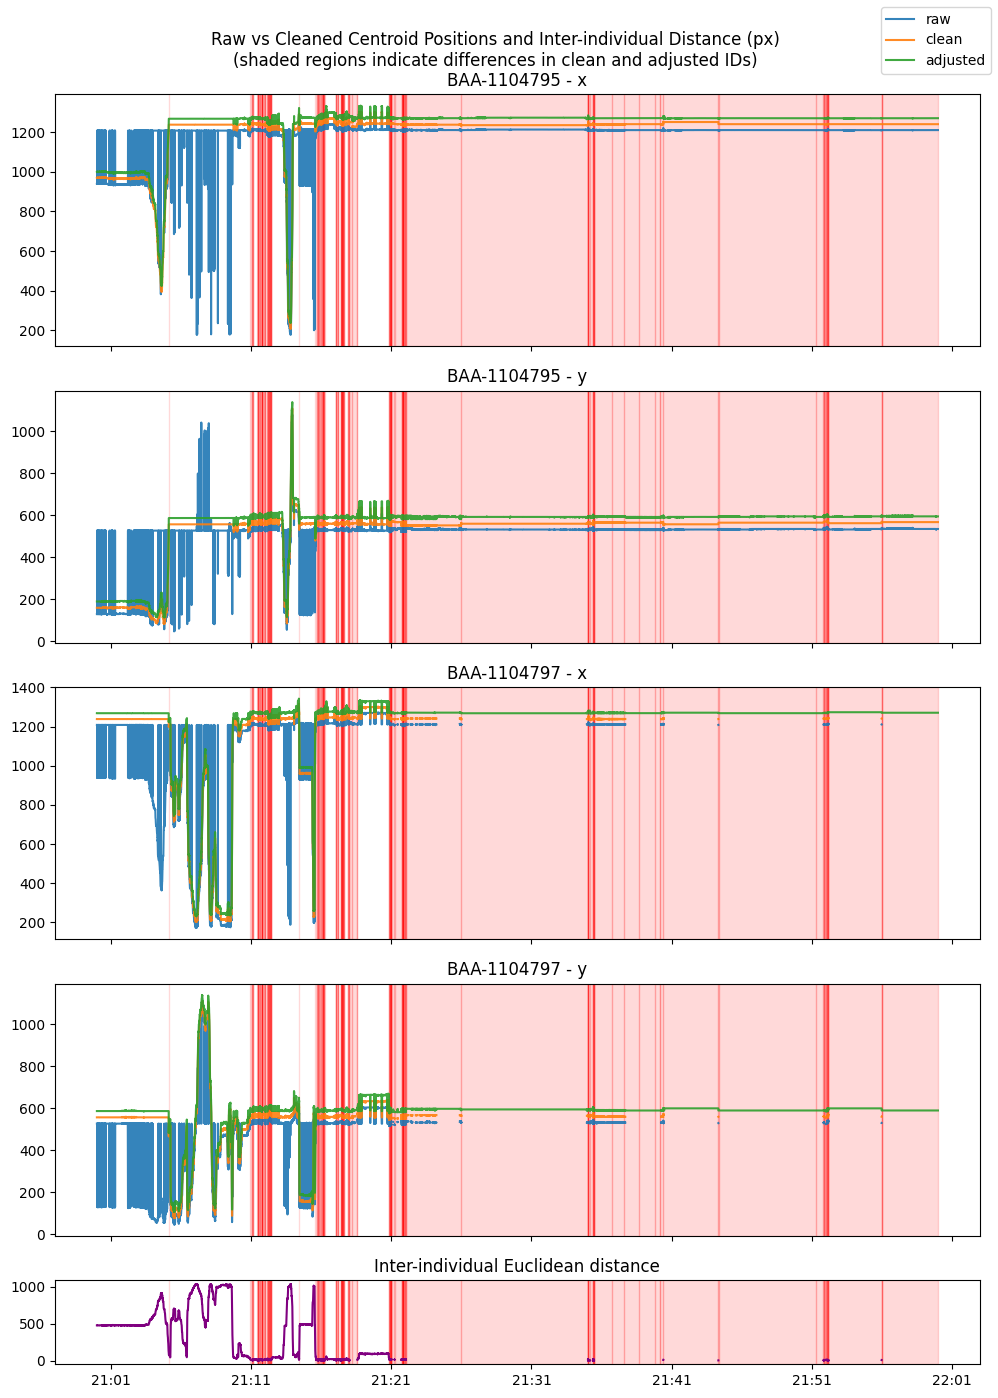

In [90]:
# Compute the difference mask between cleaned and adjusted IDs
diff_mask = (
    ds_centroid_clean.position.squeeze() != ds_centroid_adjusted.position.squeeze()
).isel(space=0, individuals=0)
# Compute inter-individual distances for the cleaned dataset
inter_ind_dist = compute_pairwise_distances(
    ds_centroid_clean.position, dim="individuals", pairs="all", metric="euclidean"
)
# Plot
spaces = ds_centroid.space.values
individuals = ds_centroid.individuals.values
nrows = len(individuals) * len(spaces)
ncols = 1
# Add 1 extra row for the inter-individual distance plot, make it shorter
height_ratios = [3] * nrows + [1]
fig, axes = plt.subplots(
    nrows=nrows + 1,
    ncols=ncols,
    figsize=(10, 3 * nrows + 2),
    sharex=True,
    gridspec_kw={"height_ratios": height_ratios},
)
axes = np.array(axes).reshape(-1)
offsets = [0, 30, 60]
datasets = [
    (ds_centroid, "raw", offsets[0]),
    (ds_centroid_clean, "clean", offsets[1]),
    (ds_centroid_adjusted, "adjusted", offsets[2]),
]
# Main plots
for i, ind in enumerate(individuals):
    for j, space in enumerate(spaces):
        ax_idx = i * len(spaces) + j
        ax = axes[ax_idx]
        for ds, label, offset in datasets:
            y = ds.position.squeeze().sel(space=space, individuals=ind)
            ax.plot(
                y.time,
                y + offset,
                linestyle="-",
                alpha=0.9,
                label=label if (ind == individuals[0] and space == spaces[0]) else None,
            )
        ax.set_title(f"{ind} - {space}")
        # Shade regions where IDs differ
        shade_mask_regions(ax, diff_mask)

# Inter-individual distance plot (bottom row)
ax_dist = axes[-1]
ax_dist.plot(
    inter_ind_dist.time,
    inter_ind_dist.values,
    color="purple",
)
# Shade regions where IDs differ
shade_mask_regions(ax_dist, diff_mask)
ax_dist.set_title("Inter-individual Euclidean distance")
# Shared legend for the main plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    ["raw", "clean", "adjusted"],
)
fig.suptitle(
    "Raw vs Cleaned Centroid Positions and Inter-individual Distance (px)\n"
    "(shaded regions indicate differences in clean and adjusted IDs)",
)
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout()
plt.show()

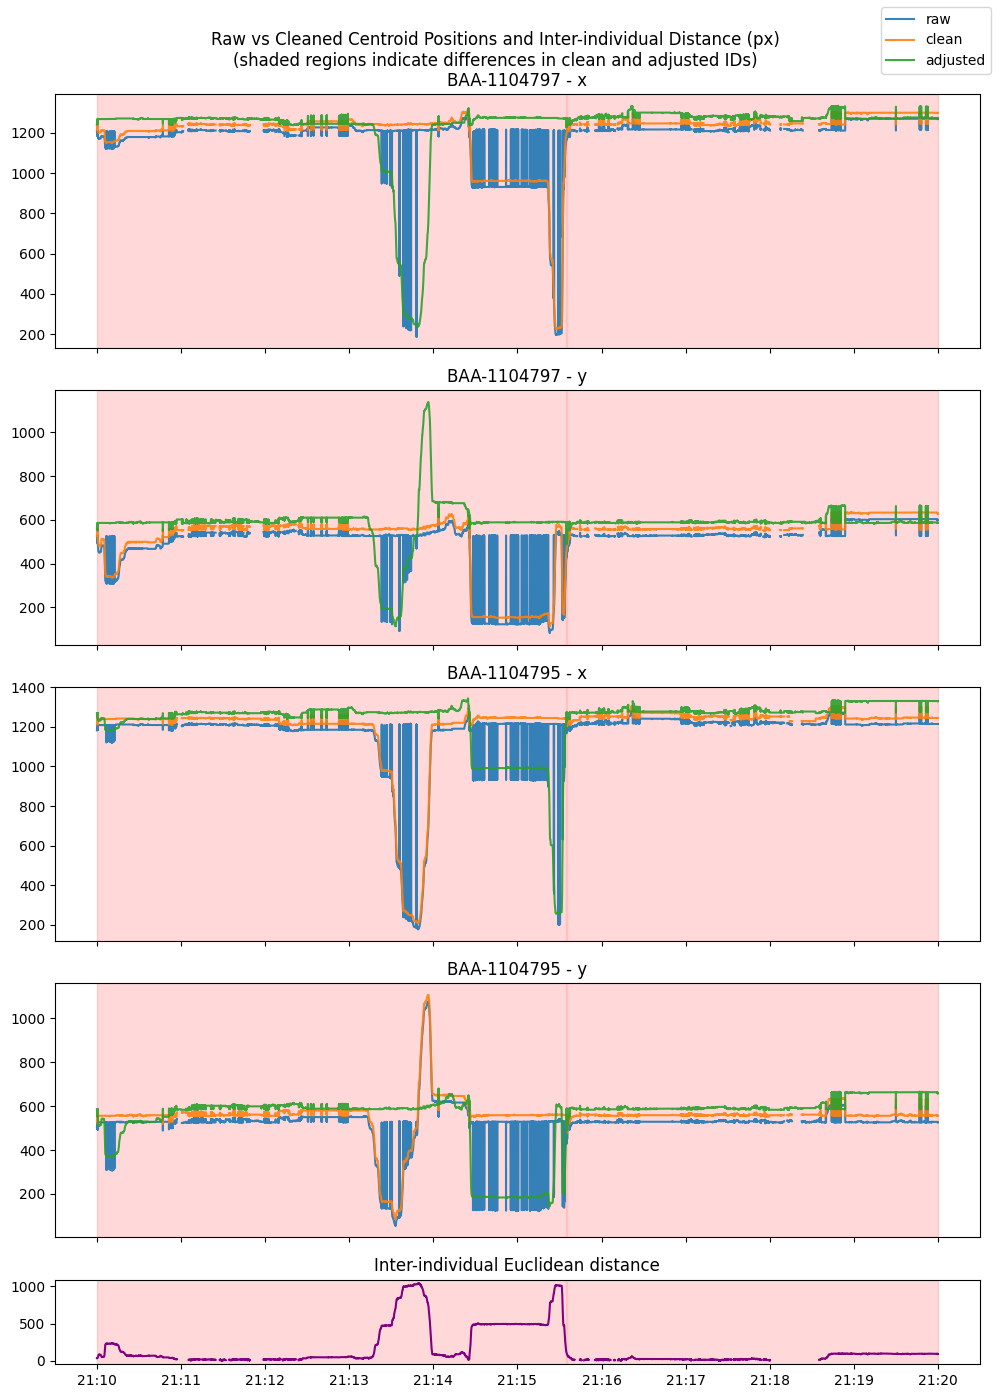

In [102]:
# Compute the difference mask between cleaned and adjusted IDs
diff_mask = (
    ds_centroid_clean.position.squeeze() != ds_centroid_adjusted.position.squeeze()
).isel(space=0, individuals=0)
# Compute inter-individual distances for the cleaned dataset
inter_ind_dist = compute_pairwise_distances(
    ds_centroid_clean.position, dim="individuals", pairs="all", metric="euclidean"
)
# Plot
spaces = ds_centroid.space.values
individuals = ds_centroid.individuals.values
nrows = len(individuals) * len(spaces)
ncols = 1
# Add 1 extra row for the inter-individual distance plot, make it shorter
height_ratios = [3] * nrows + [1]
fig, axes = plt.subplots(
    nrows=nrows + 1,
    ncols=ncols,
    figsize=(10, 3 * nrows + 2),
    sharex=True,
    gridspec_kw={"height_ratios": height_ratios},
)
axes = np.array(axes).reshape(-1)
offsets = [0, 30, 60]
datasets = [
    (ds_centroid, "raw", offsets[0]),
    (ds_centroid_clean, "clean", offsets[1]),
    (ds_centroid_adjusted, "adjusted", offsets[2]),
]
# Main plots
for i, ind in enumerate(individuals):
    for j, space in enumerate(spaces):
        ax_idx = i * len(spaces) + j
        ax = axes[ax_idx]
        for ds, label, offset in datasets:
            y = ds.position.squeeze().sel(space=space, individuals=ind)
            ax.plot(
                y.time,
                y + offset,
                linestyle="-",
                alpha=0.9,
                label=label if (ind == individuals[0] and space == spaces[0]) else None,
            )
        ax.set_title(f"{ind} - {space}")
        # Shade regions where IDs differ
        shade_mask_regions(ax, diff_mask)

# Inter-individual distance plot (bottom row)
ax_dist = axes[-1]
ax_dist.plot(
    inter_ind_dist.time,
    inter_ind_dist.values,
    color="purple",
)
# Shade regions where IDs differ
shade_mask_regions(ax_dist, diff_mask)
ax_dist.set_title("Inter-individual Euclidean distance")
# Shared legend for the main plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    ["raw", "clean", "adjusted"],
)
fig.suptitle(
    "Raw vs Cleaned Centroid Positions and Inter-individual Distance (px)\n"
    "(shaded regions indicate differences in clean and adjusted IDs)",
)
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout()
plt.show()

In [67]:
ds_centroid_clean.position.squeeze().isel(time=slice(32854, 32874))

<xarray.DataArray 'position' (time: 20, space: 2, individuals: 2)> Size: 640B
1.214e+03 1.203e+03 541.7 522.9 1.214e+03 ... 522.9 nan 1.203e+03 nan 522.9
Coordinates:
  * space            (space) <U1 8B 'x' 'y'
    keypoints        <U8 32B 'centroid'
  * individuals      (individuals) <U11 88B 'BAA-1104795' 'BAA-1104797'
  * time             (time) datetime64[ns] 160B 2024-08-28T21:10:57.080000 .....
    seconds_elapsed  (time) float64 160B 657.1 657.1 657.1 ... 657.4 657.4 657.5

In [60]:
ds_centroid_clean.position.squeeze().isel(time=slice(32854, 32858))

<xarray.DataArray 'position' (time: 4, space: 2, individuals: 2)> Size: 128B
1.214e+03 1.203e+03 541.7 522.9 1.214e+03 ... 522.9 nan 1.203e+03 nan 522.9
Coordinates:
  * space            (space) <U1 8B 'x' 'y'
    keypoints        <U8 32B 'centroid'
  * individuals      (individuals) <U11 88B 'BAA-1104795' 'BAA-1104797'
  * time             (time) datetime64[ns] 32B 2024-08-28T21:10:57.080000 ......
    seconds_elapsed  (time) float64 32B 657.1 657.1 657.1 657.1

In [53]:
idx

array([ 32856,  32857,  32858, ..., 174569, 174570, 174574], dtype=int64)

In [46]:
(
    ds_centroid_clean.position.squeeze() != ds_centroid_adjusted.position.squeeze()
).isel(space=0, individuals=0).values.shape

(180001,)

In [41]:
(
    ds_centroid_clean.position.squeeze() != ds_centroid_adjusted.position.squeeze()
).isel(space=0, individuals=0)

<xarray.DataArray 'position' (time: 180001)> Size: 180kB
False False False False False False False ... True True True True True True True
Coordinates:
    space            <U1 4B 'x'
    keypoints        <U8 32B 'centroid'
    individuals      <U11 44B 'BAA-1104795'
  * time             (time) datetime64[ns] 1MB 2024-08-28T21:00:00 ... 2024-0...
    seconds_elapsed  (time) float64 1MB 0.0 0.02 0.04 ... 3.6e+03 3.6e+03

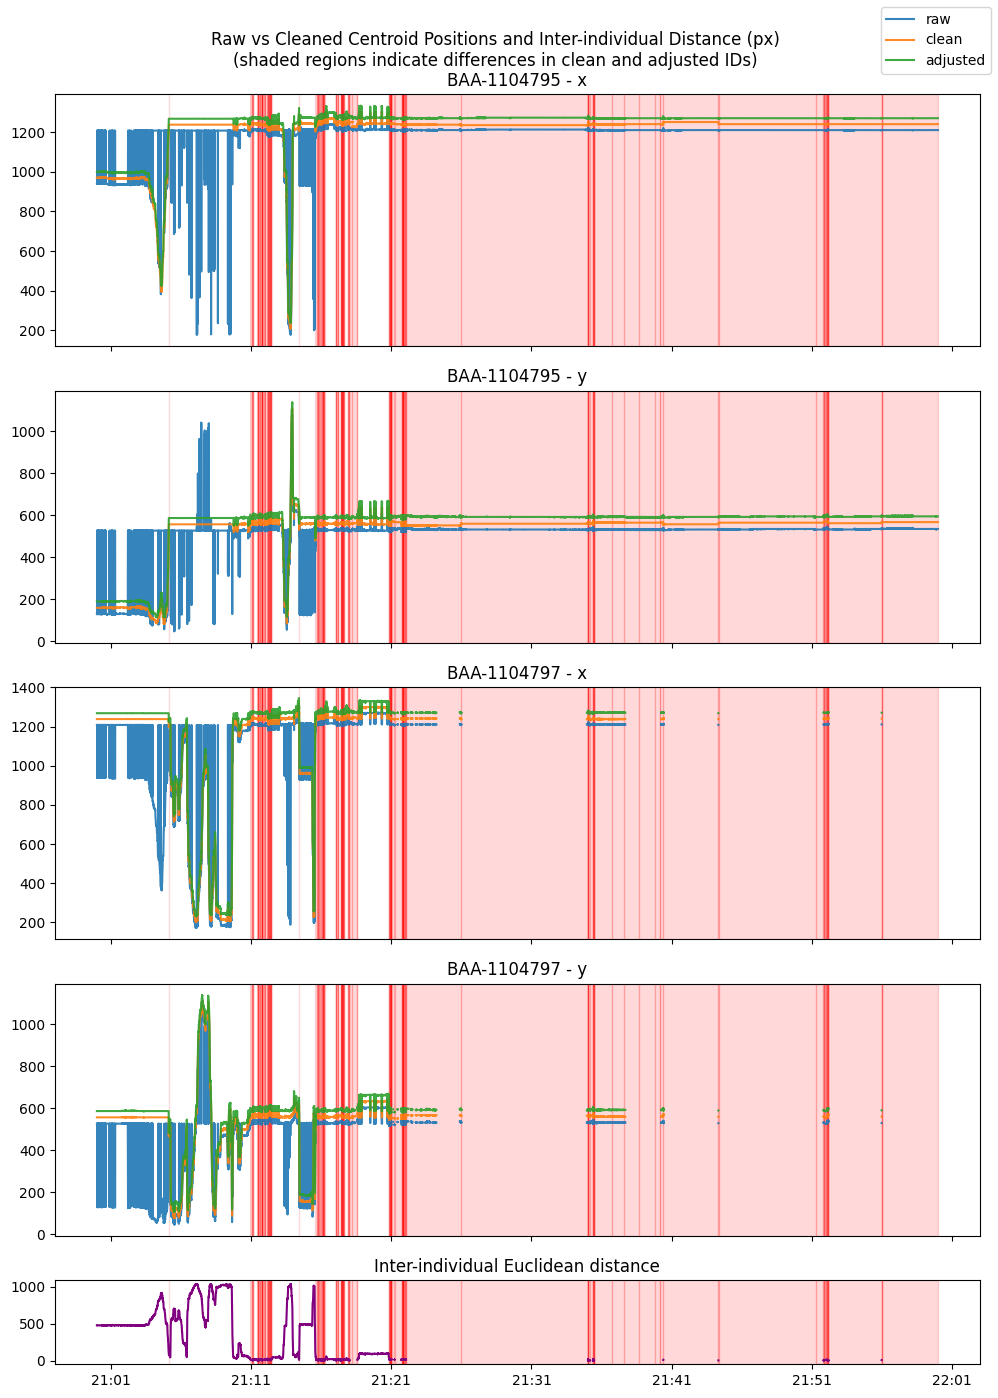

In [ ]:
# Compute the difference mask between cleaned and adjusted IDs
diff_mask = (
    ds_centroid_clean.position.squeeze() != ds_centroid_adjusted.position.squeeze()
).isel(space=0, individuals=0)
diff_mask = ~(xr.ufuncs.isclose(ds_centroid_clean.position.squeeze(), ds_centroid_adjusted.position.squeeze(), equal_nan=True)).isel(space=0, individuals=0)
# Compute inter-individual distances for the cleaned dataset
inter_ind_dist = compute_pairwise_distances(
    ds_centroid_clean.position, dim="individuals", pairs="all", metric="euclidean"
)
# Plot
spaces = ds_centroid.space.values
individuals = ds_centroid.individuals.values
nrows = len(individuals) * len(spaces)
ncols = 1
# Add 1 extra row for the inter-individual distance plot, make it shorter
height_ratios = [3] * nrows + [1]
fig, axes = plt.subplots(
    nrows=nrows + 1,
    ncols=ncols,
    figsize=(10, 3 * nrows + 2),
    sharex=True,
    gridspec_kw={"height_ratios": height_ratios},
)
axes = np.array(axes).reshape(-1)
offsets = [0, 30, 60]
datasets = [
    (ds_centroid, "raw", offsets[0]),
    (ds_centroid_clean, "clean", offsets[1]),
    (ds_centroid_adjusted, "adjusted", offsets[2]),
]
# Main plots
for i, ind in enumerate(individuals):
    for j, space in enumerate(spaces):
        ax_idx = i * len(spaces) + j
        ax = axes[ax_idx]
        for ds, label, offset in datasets:
            y = ds.position.squeeze().sel(space=space, individuals=ind)
            ax.plot(
                y.time,
                y + offset,
                linestyle="-",
                alpha=0.9,
                label=label if (ind == individuals[0] and space == spaces[0]) else None,
            )
        ax.set_title(f"{ind} - {space}")
        # Shade regions where IDs differ
        shade_mask_regions(ax, diff_mask)

# Inter-individual distance plot (bottom row)
ax_dist = axes[-1]
ax_dist.plot(
    inter_ind_dist.time,
    inter_ind_dist.values,
    color="purple",
)
# Shade regions where IDs differ
shade_mask_regions(ax_dist, diff_mask)
ax_dist.set_title("Inter-individual Euclidean distance")
# Shared legend for the main plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    ["raw", "clean", "adjusted"],
)
fig.suptitle(
    "Raw vs Cleaned Centroid Positions and Inter-individual Distance (px)\n"
    "(shaded regions indicate differences in clean and adjusted IDs)",
)
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout()
plt.show()

## Compute and plot speed (cm/s)

In [27]:
PIXEL_SCALE = 0.192  # 1 px = 0.192 cm
# Compute speed in cm/s for both raw and cleaned centroid positions
ds_centroid["speed_cm_per_sec"] = compute_speed(
    scale(
        ds_centroid.position.set_index(time="seconds_elapsed"),
        factor=PIXEL_SCALE,
        space_unit="cm",
    )
).assign_coords(
    time=ds_centroid.time,
)
ds_centroid_clean["speed_cm_per_sec"] = compute_speed(
    scale(
        ds_centroid_clean.position.set_index(time="seconds_elapsed"),
        factor=PIXEL_SCALE,
        space_unit="cm",
    )
).assign_coords(
    time=ds_centroid_clean.time,
)
ds_centroid_adjusted["speed_cm_per_sec"] = compute_speed(
    scale(
        ds_centroid_adjusted.position.set_index(time="seconds_elapsed"),
        factor=PIXEL_SCALE,
        space_unit="cm",
    )
).assign_coords(
    time=ds_centroid_adjusted.time,
)

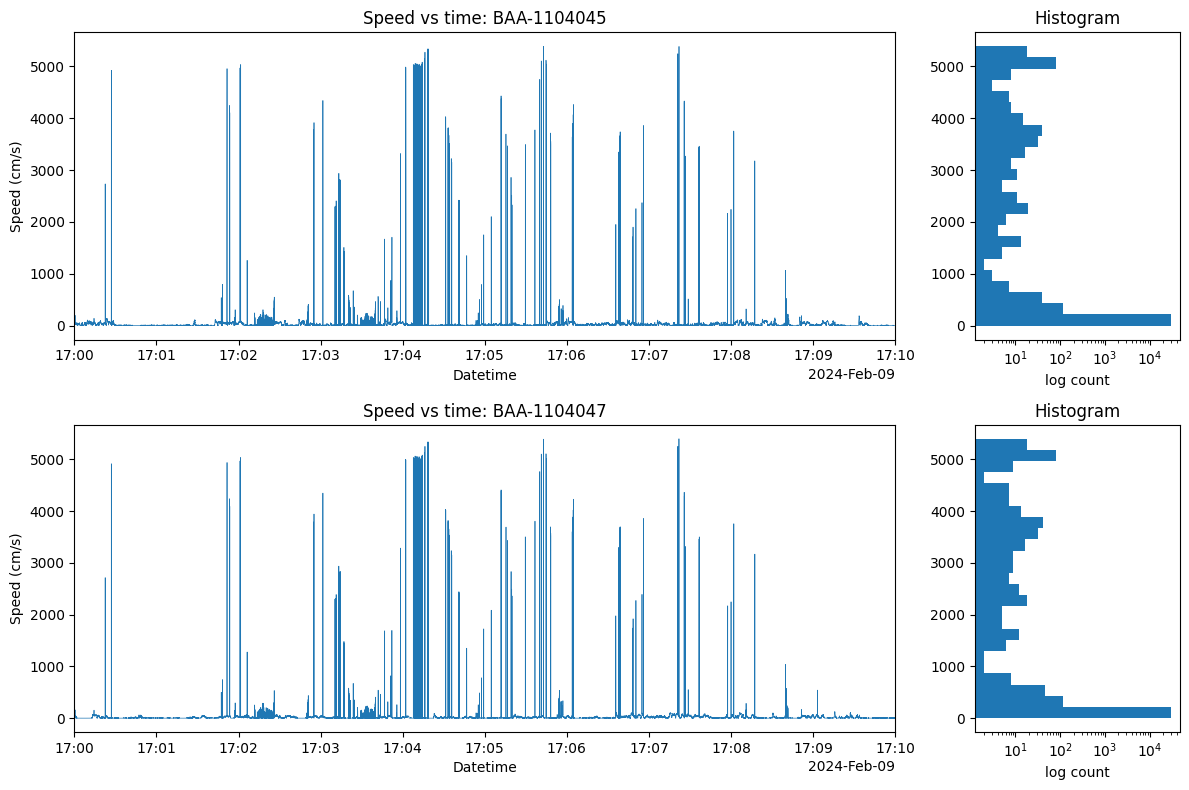

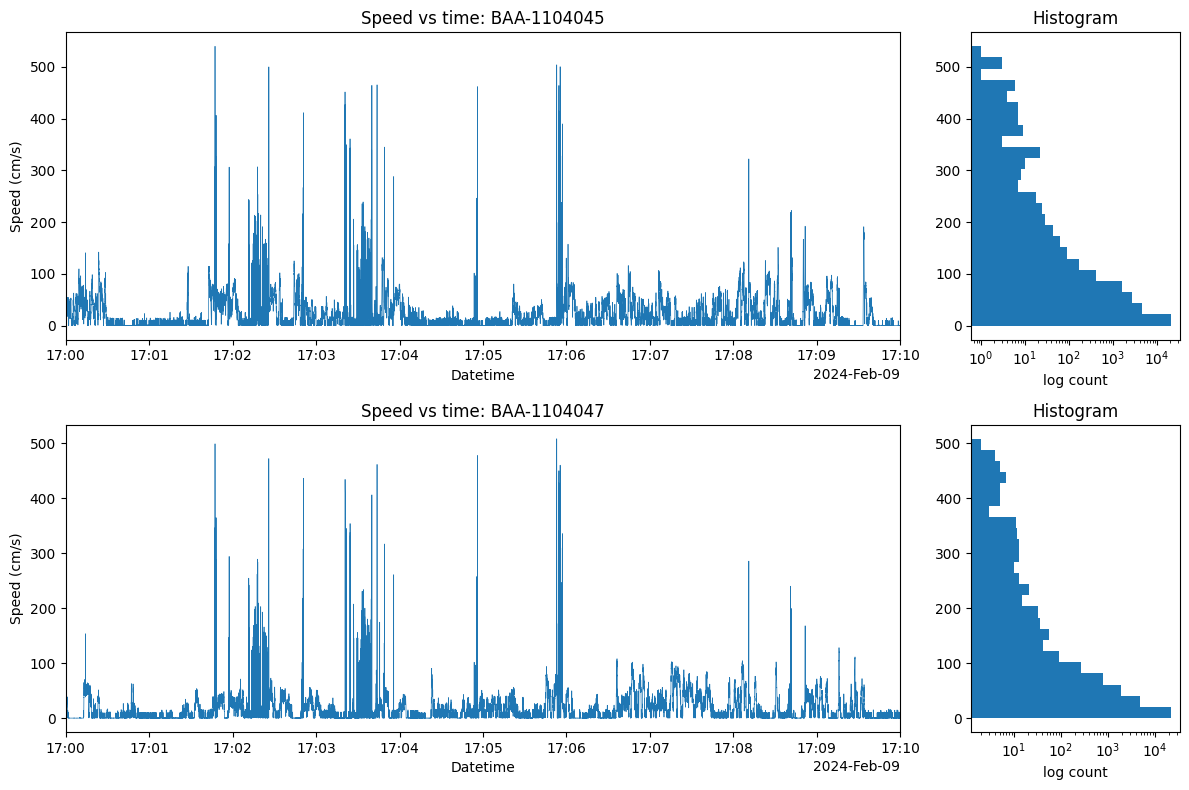

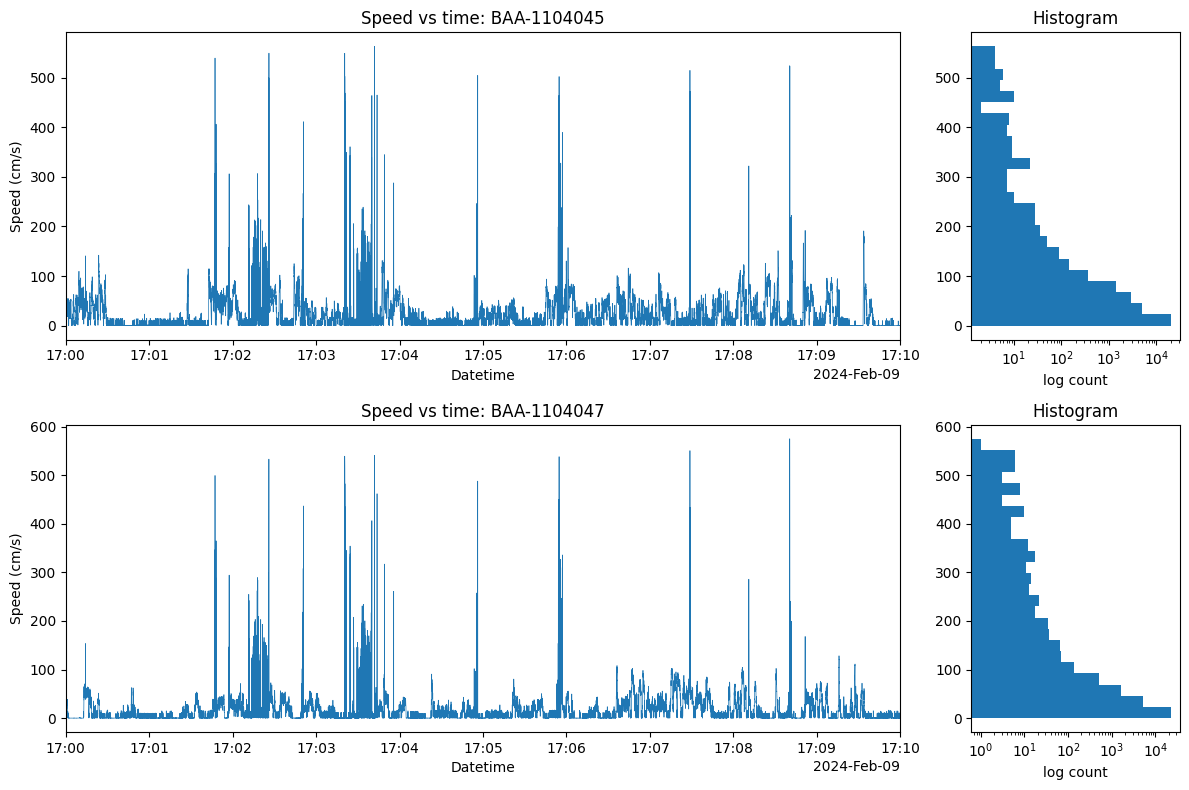

In [31]:
plot_speed(ds_centroid.speed_cm_per_sec.sel(keypoints="centroid"))
plot_speed(ds_centroid_clean.speed_cm_per_sec.sel(keypoints="centroid"))
plot_speed(ds_centroid_adjusted.speed_cm_per_sec.sel(keypoints="centroid"))

## Save to netCDF file for visualisation in movement GUI

In [ ]:
ds_centroid.to_netcdf("raw-centroid_2024-02-09-17-00-00_social0.2-aeon3.nc")
ds_centroid_clean.to_netcdf("clean-centroid_2024-02-09-17-00-00_social0.2-aeon3.nc")
ds_centroid_adjusted.to_netcdf(
    "review-clean-centroid_2024-02-09-17-00-00_social0.2-aeon3.nc"
)